# 03 — Modeling & Evaluation
Train and compare Random Forest vs XGBoost for salary band classification.
Features: structured job data + NLP-derived TF-IDF/LLM features.

In [2]:
import sys
!{sys.executable} -m pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 330.3 kB/s eta 0:05:08
   ---------------------------------------- 0.0/101.7 MB 393.8 kB/s eta 0:04:19
   ---------------------------------------- 0.1/101.7 MB 1.1 MB/s eta 0:01:36
   ---------------------------------------- 0.3/101.7 MB 1.7 MB/s eta 0:00:59
   ---------------------------------------- 0.5/101.7 MB 2.2 MB/s eta 0:00:48
   ---------------------------------------- 0.7/101.7 MB 2.6 MB/s eta 0:00:40
   ---------------------------------------- 0.9/101.7 MB 2.8 MB/s eta 0:00:37
   ---------------------------------------- 1.1/101.7 MB 3.1 MB/s eta 0:00:33
    --------------------------------------- 1.4/101.7 MB 3.3 MB/s eta 0:00:31
    --------------------------------------- 1.6/101.7 MB 3.6 MB/s eta 0:00:28
    --------------------------------------- 1.9/101.7 MB 3.8 MB/s eta 0:00:27
    --------------------------------------- 2.2/101.7 MB 4.0 MB/s e

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import xgboost as xgb

sns.set_theme(style='whitegrid')

## 1. Load & Prepare Features

In [5]:
df = pd.read_csv('../data/processed/job_postings_with_llm_features.csv')
print(f'Shape: {df.shape}')
print(df['salary_band'].value_counts())

Shape: (26866, 13)
salary_band
Mid (50–90k)         9762
High (90–140k)       8390
Very High (>140k)    4562
Low (<50k)           4152
Name: count, dtype: int64


In [6]:
# --- Structured features ---
le_exp = LabelEncoder()
le_work = LabelEncoder()

df['exp_encoded'] = le_exp.fit_transform(df['formatted_experience_level'].fillna('Unknown'))
df['work_encoded'] = le_work.fit_transform(df['formatted_work_type'].fillna('Unknown'))

# --- LLM features ---
le_domain = LabelEncoder()
le_seniority = LabelEncoder()

df['domain_encoded'] = le_domain.fit_transform(df['domain'].fillna('other'))
df['seniority_encoded'] = le_seniority.fit_transform(df['seniority_implied'].fillna('unknown'))
df['remote_int'] = df['remote_friendly'].astype(int) if df['remote_friendly'].dtype == bool else df['remote_friendly'].map({'True': 1, 'False': 0, True: 1, False: 0}).fillna(0).astype(int)

# --- TF-IDF features ---
import re
def clean_text(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['description_clean'] = df['description'].apply(clean_text)

tfidf = TfidfVectorizer(max_features=200, stop_words='english', ngram_range=(1, 2), min_df=2)
svd = TruncatedSVD(n_components=30, random_state=42)
tfidf_matrix = tfidf.fit_transform(df['description_clean'])
tfidf_reduced = svd.fit_transform(tfidf_matrix)

tfidf_df = pd.DataFrame(tfidf_reduced, columns=[f'tfidf_{i}' for i in range(30)], index=df.index)

# --- Target ---
le_target = LabelEncoder()
y = le_target.fit_transform(df['salary_band'].astype(str))

print('Classes:', le_target.classes_)

Classes: ['High (90–140k)' 'Low (<50k)' 'Mid (50–90k)' 'Very High (>140k)']


In [7]:
# Combine all features
structured_cols = ['exp_encoded', 'work_encoded', 'domain_encoded', 'seniority_encoded', 'remote_int']
X_structured = df[structured_cols]
X = pd.concat([X_structured.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)

print(f'Feature matrix shape: {X.shape}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Feature matrix shape: (26866, 35)
Train: (21492, 35), Test: (5374, 35)


## 2. Model A — Random Forest

In [9]:
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}')
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

=== Random Forest ===
Accuracy: 0.604
                   precision    recall  f1-score   support

   High (90–140k)       0.57      0.65      0.61      1678
       Low (<50k)       0.76      0.46      0.57       830
     Mid (50–90k)       0.58      0.75      0.65      1953
Very High (>140k)       0.73      0.34      0.47       913

         accuracy                           0.60      5374
        macro avg       0.66      0.55      0.57      5374
     weighted avg       0.63      0.60      0.59      5374



## 3. Model B — XGBoost

In [11]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print('=== XGBoost ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}')
print(classification_report(y_test, y_pred_xgb, target_names=le_target.classes_))

C:\Users\ece_l\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:35:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost ===
Accuracy: 0.605
                   precision    recall  f1-score   support

   High (90–140k)       0.57      0.61      0.59      1678
       Low (<50k)       0.70      0.54      0.61       830
     Mid (50–90k)       0.60      0.70      0.65      1953
Very High (>140k)       0.63      0.44      0.52       913

         accuracy                           0.60      5374
        macro avg       0.62      0.57      0.59      5374
     weighted avg       0.61      0.60      0.60      5374



## 4. Model Comparison

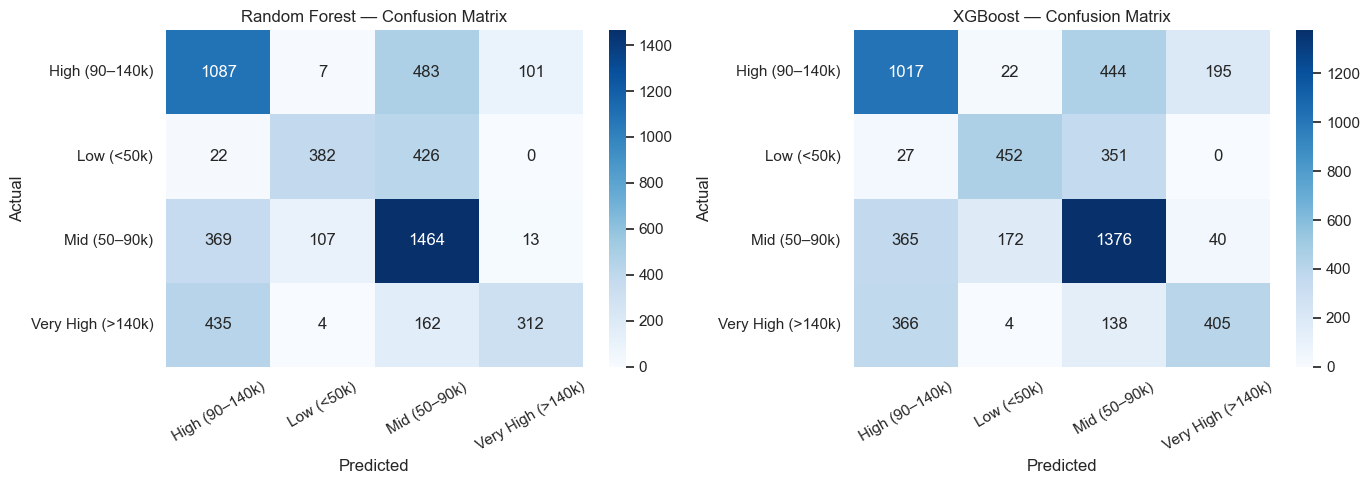

           Model  Accuracy
0  Random Forest  0.603833
1        XGBoost  0.604764


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le_target.classes_, yticklabels=le_target.classes_)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../docs/figures/05_confusion_matrices.png', dpi=150)
plt.show()

# Summary table
summary = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb)]
})
summary.to_csv('../docs/ml_metrics.csv', index=False)
print(summary)

## 5. Feature Importance

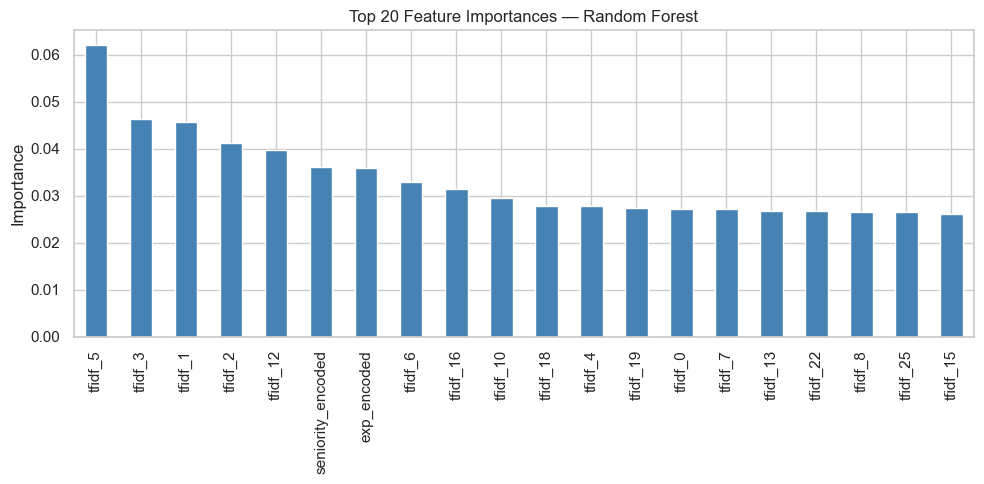

In [15]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Top 20 Feature Importances — Random Forest')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('../docs/figures/06_feature_importance.png', dpi=150)
plt.show()

## 6. Save Best Model

In [17]:
# Save models and encoders
with open('../src/rf_model.pkl', 'wb') as f: pickle.dump(rf, f)
with open('../src/xgb_model.pkl', 'wb') as f: pickle.dump(xgb_model, f)
with open('../src/tfidf_vectorizer.pkl', 'wb') as f: pickle.dump(tfidf, f)
with open('../src/svd.pkl', 'wb') as f: pickle.dump(svd, f)
with open('../src/label_encoder_target.pkl', 'wb') as f: pickle.dump(le_target, f)
with open('../src/label_encoder_exp.pkl', 'wb') as f: pickle.dump(le_exp, f)
with open('../src/label_encoder_work.pkl', 'wb') as f: pickle.dump(le_work, f)
with open('../src/label_encoder_domain.pkl', 'wb') as f: pickle.dump(le_domain, f)
with open('../src/label_encoder_seniority.pkl', 'wb') as f: pickle.dump(le_seniority, f)

print('All models and encoders saved to src/')

All models and encoders saved to src/
